### We will test previous work of Supervised approach but we would also expand it for all types to see what results we get

In [ ]:
# Imports

import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import sys
from astropy.io import fits
from scipy.ndimage import zoom


f = h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r')
list(f.keys())

['classes',
 'data',
 'flag_map',
 'freq_range',
 'labels',
 'rfi_corrected',
 'time_range',
 'timestamps']

In [2]:
dset = f['data']
dset.shape

(8147, 500, 800)

Print the list from the dataset

In [ ]:
# Open the H5 file in read mode
with h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r') as file:
    print("Keys: %s" % file.keys())
    a_group_key = list(file.keys())[4] # See the data of [index] key
    
    # Getting the data
    data = list(file[a_group_key])
    print(data)

Print specific indeces with a specific type

In [12]:
with h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r') as file:
    print("Keys:", list(file.keys()))
    
    a_group_key = list(file.keys())[4]  # Replace with actual key or index if needed
    
    # Load the actual data
    data = list(file[a_group_key])
    
    # Convert to NumPy array
    data_array = np.array(data)
    
    # Find indices where value == 2
    indices = np.where(data_array == np.int64(2))[0]
    
    print("Indices with value 2:", indices)

Keys: ['classes', 'data', 'flag_map', 'freq_range', 'labels', 'rfi_corrected', 'time_range', 'timestamps']
Indices with value 2: [   2  229 1115 1511 1516 1532 1547 1582 1601 1722 1726 1914 2260 2791]


(8147, 500, 800)

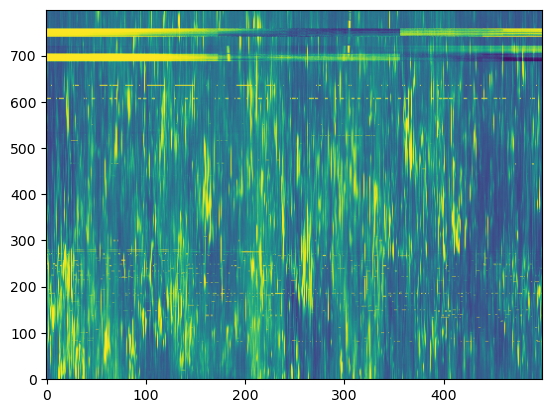

In [6]:
plt.imshow(dset[1, :, :].T, origin='lower', aspect='auto')
dset.shape

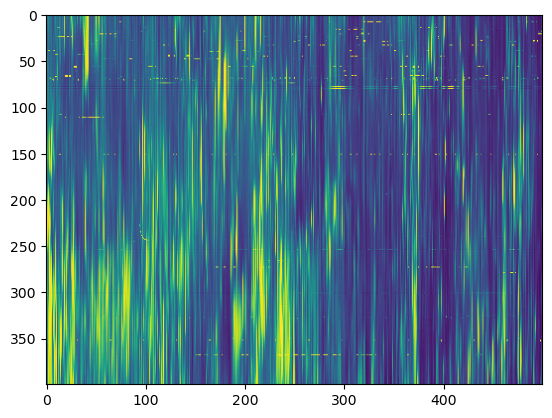

In [42]:
dataset = dset[:, :, 200:600]
plt.imshow(dataset[30, :, :].T, aspect='auto')

In [35]:
# Normalize the data from mattia code

def sigmoid(x, s, c):
    return 1 / (1 + np.exp(-(x - c) / s))

def resize_np(image, new_shape):
    """Resize a 2D numpy array to new_shape using scipy.ndimage.zoom."""
    zoom_factors = (new_shape[0] / image.shape[0], new_shape[1] / image.shape[1])
    return zoom(image, zoom_factors, order=1)  # order=1: bilinear interpolation

def download_and_normalize(dset):
    imdata = dset[0, :, :].T  # Assuming dset is a numpy array with shape (N, M)

    normalization = np.mean(
        np.sort(imdata, 0)[
            int(imdata.shape[0] * 0.1):int(imdata.shape[0] * 0.3), :
        ], 0
    )
    normalized = imdata / normalization
    vmin, vmax = np.percentile(normalized, (20, 80))
    center = np.mean([vmax, vmin])
    scale = vmax - vmin
    normalized = sigmoid(normalized, scale, center)

    # Resize to (500, 800) using scipy
    resized = resize_np(normalized, (500, 800))
    return resized

(500, 800)

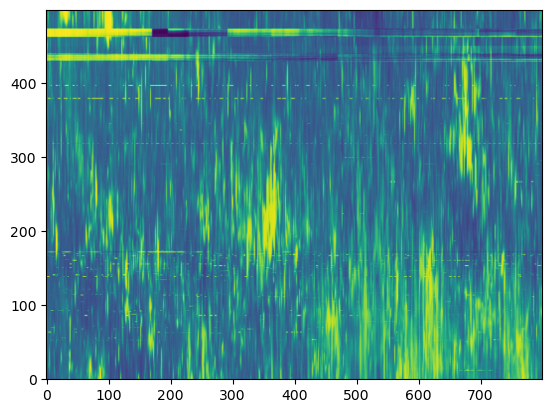

In [36]:
image = download_and_normalize(dset)

plt.imshow(image[:, :], origin='lower', aspect='auto')
image.shape